## 1. Dataset

```https://www.kaggle.com/datasets/ziya07/smart-logistics-supply-chain-dataset```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from importlib import reload


import seaborn as sns
from sklearn import tree
from sklearn.feature_selection import mutual_info_classif
from collections import defaultdict

from tqdm import tqdm
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, classification_report

import inspect


sys.path.append('/Users/cheungjustin/PycharmProjects/CIBer')
import util as put
import stats as pstats
import analytics as pan
import plot as pplot

In [2]:
df = pd.read_csv('../Raw/smart_logistics_dataset.csv')
df = df.set_index('Timestamp')
df

,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Logistics_Delay_Reason,Asset_Utilization,Demand_Forecast,Logistics_Delay
Timestamp,,,,,,,,,,,,,,,
2024-03-20 00:11:14,Truck_7,-65.7383,11.2497,390,Delayed,27.0,67.8,Detour,38,320,4,NaN,60.1,285,1
2024-10-30 07:53:51,Truck_6,22.2748,-131.7086,491,In Transit,22.5,54.3,Heavy,16,439,7,Weather,80.9,174,1
2024-07-29 18:42:48,Truck_10,54.9232,79.5455,190,In Transit,25.2,62.2,Detour,34,355,3,NaN,99.2,260,0
2024-10-28 00:50:54,Truck_9,42.3900,-1.4788,330,Delivered,25.4,52.3,Heavy,37,227,5,Traffic,97.4,160,1
2024-09-27 15:52:58,Truck_7,-65.8477,47.9468,480,Delayed,20.5,57.2,Clear,56,197,6,NaN,71.6,270,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-22 16:30:00,Truck_6,89.8701,73.6867,264,Delivered,26.9,70.0,Heavy,32,188,1,Weather,79.2,213,1
2024-04-30 04:58:58,Truck_5,-10.4792,-177.1239,479,Delivered,23.7,77.9,Detour,56,276,7,Weather,83.7,272,0
2024-10-27 22:09:13,Truck_2,-71.0609,75.3714,347,In Transit,21.0,63.1,Detour,35,382,5,NaN,74.8,275,0


In [3]:
target = 'Logistics_Delay'
cont_thres = 20
random_state = 4012

## 2. EDA Wrapper

In [4]:
dta = pan.DataAnalyzer(df, target=target, cont_thres=cont_thres, random_state=random_state)

Continuous Columns:
	Latitude
	Longitude
	Inventory_Level
	Temperature
	Humidity
	Waiting_Time
	User_Transaction_Amount
	Asset_Utilization
	Demand_Forecast 

Discrete Columns Encoding:
	Asset_ID: {'Truck_1': 0, 'Truck_10': 1, 'Truck_2': 2, 'Truck_3': 3, 'Truck_4': 4, 'Truck_5': 5, 'Truck_6': 6, 'Truck_7': 7, 'Truck_8': 8, 'Truck_9': 9}
	Shipment_Status: {'Delayed': 0, 'Delivered': 1, 'In Transit': 2}
	Traffic_Status: {'Clear': 0, 'Detour': 1, 'Heavy': 2}
	User_Purchase_Frequency: {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7, 9: 8, 10: 9}
	Logistics_Delay_Reason: {'Mechanical Failure': 0, 'Traffic': 1, 'Weather': 2, 'nan': 3}
	Logistics_Delay: {0: 0, 1: 1}


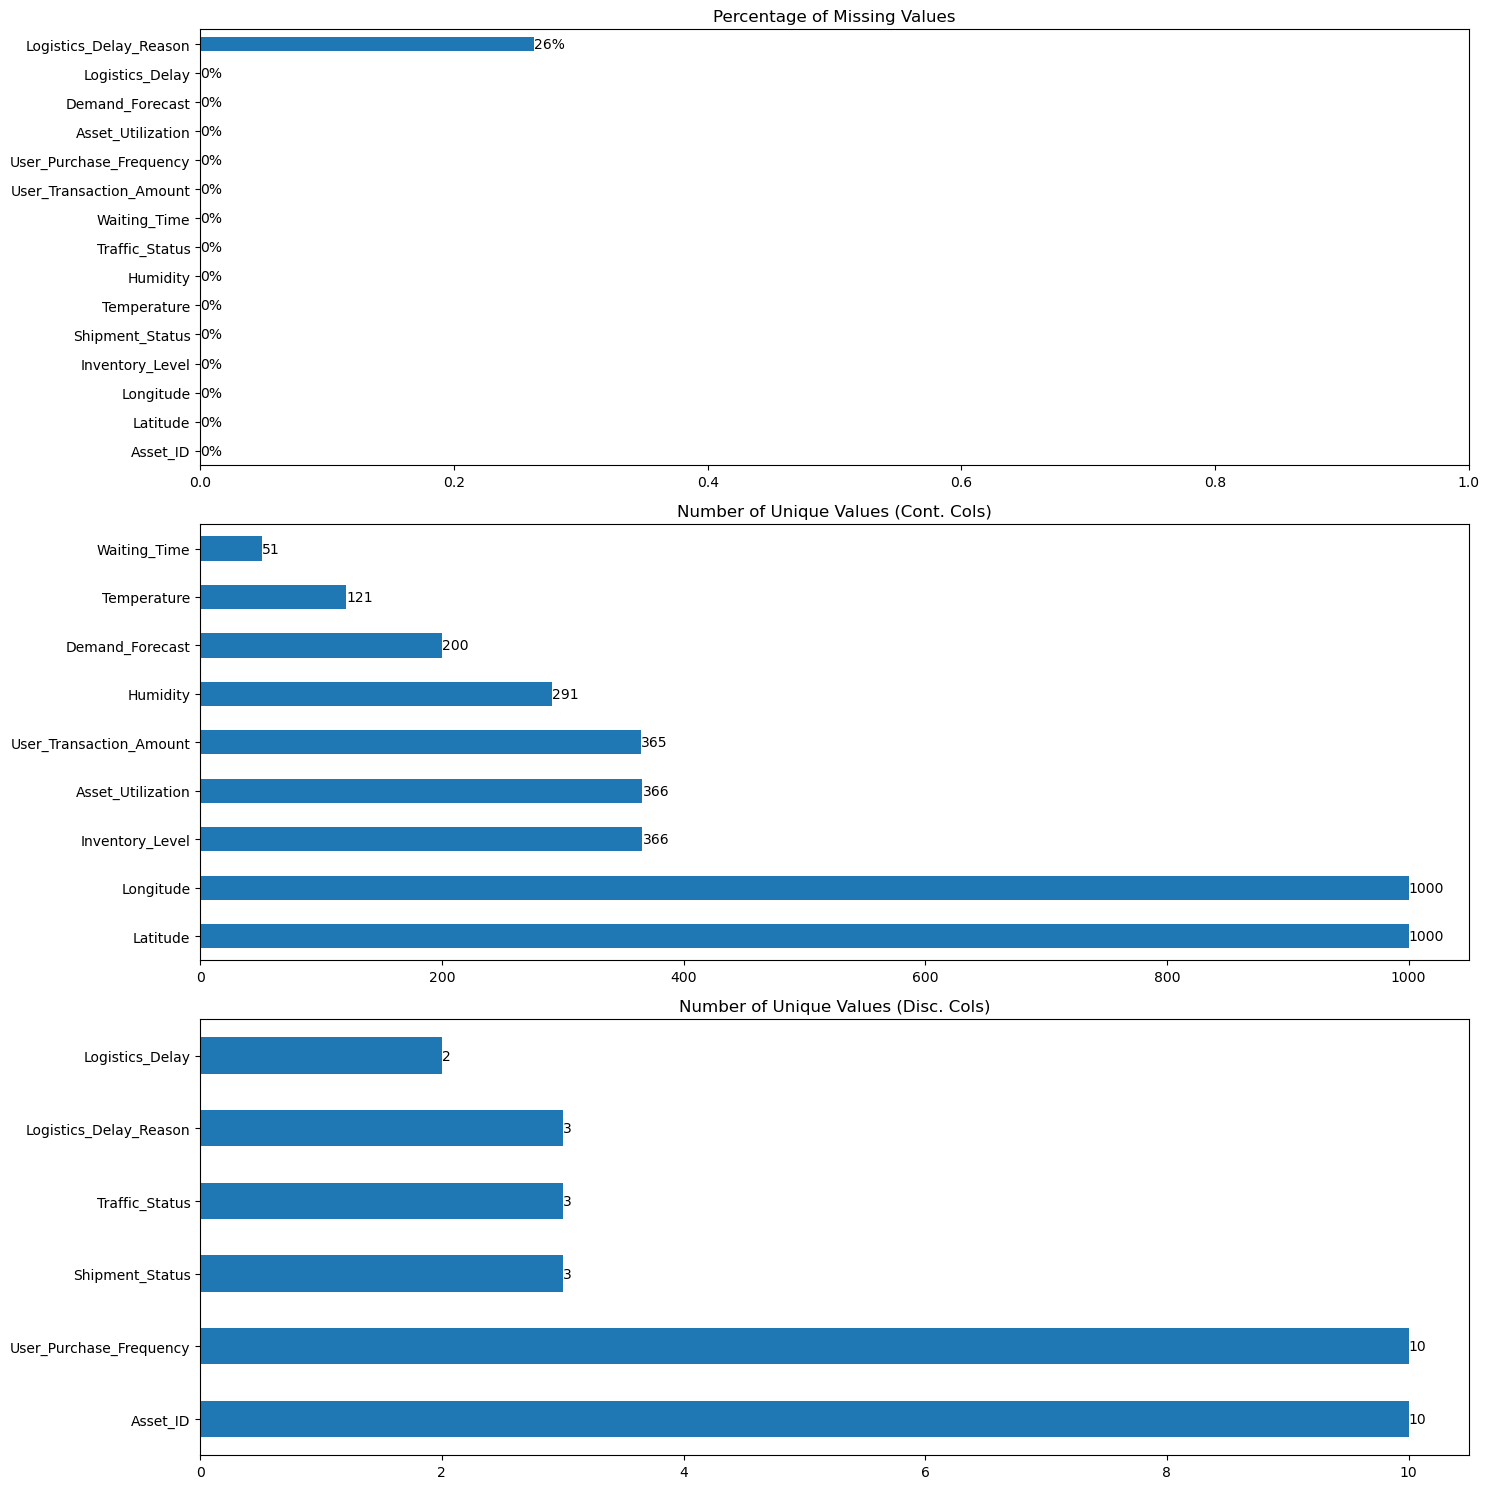

In [5]:
dta.data_quality_check()

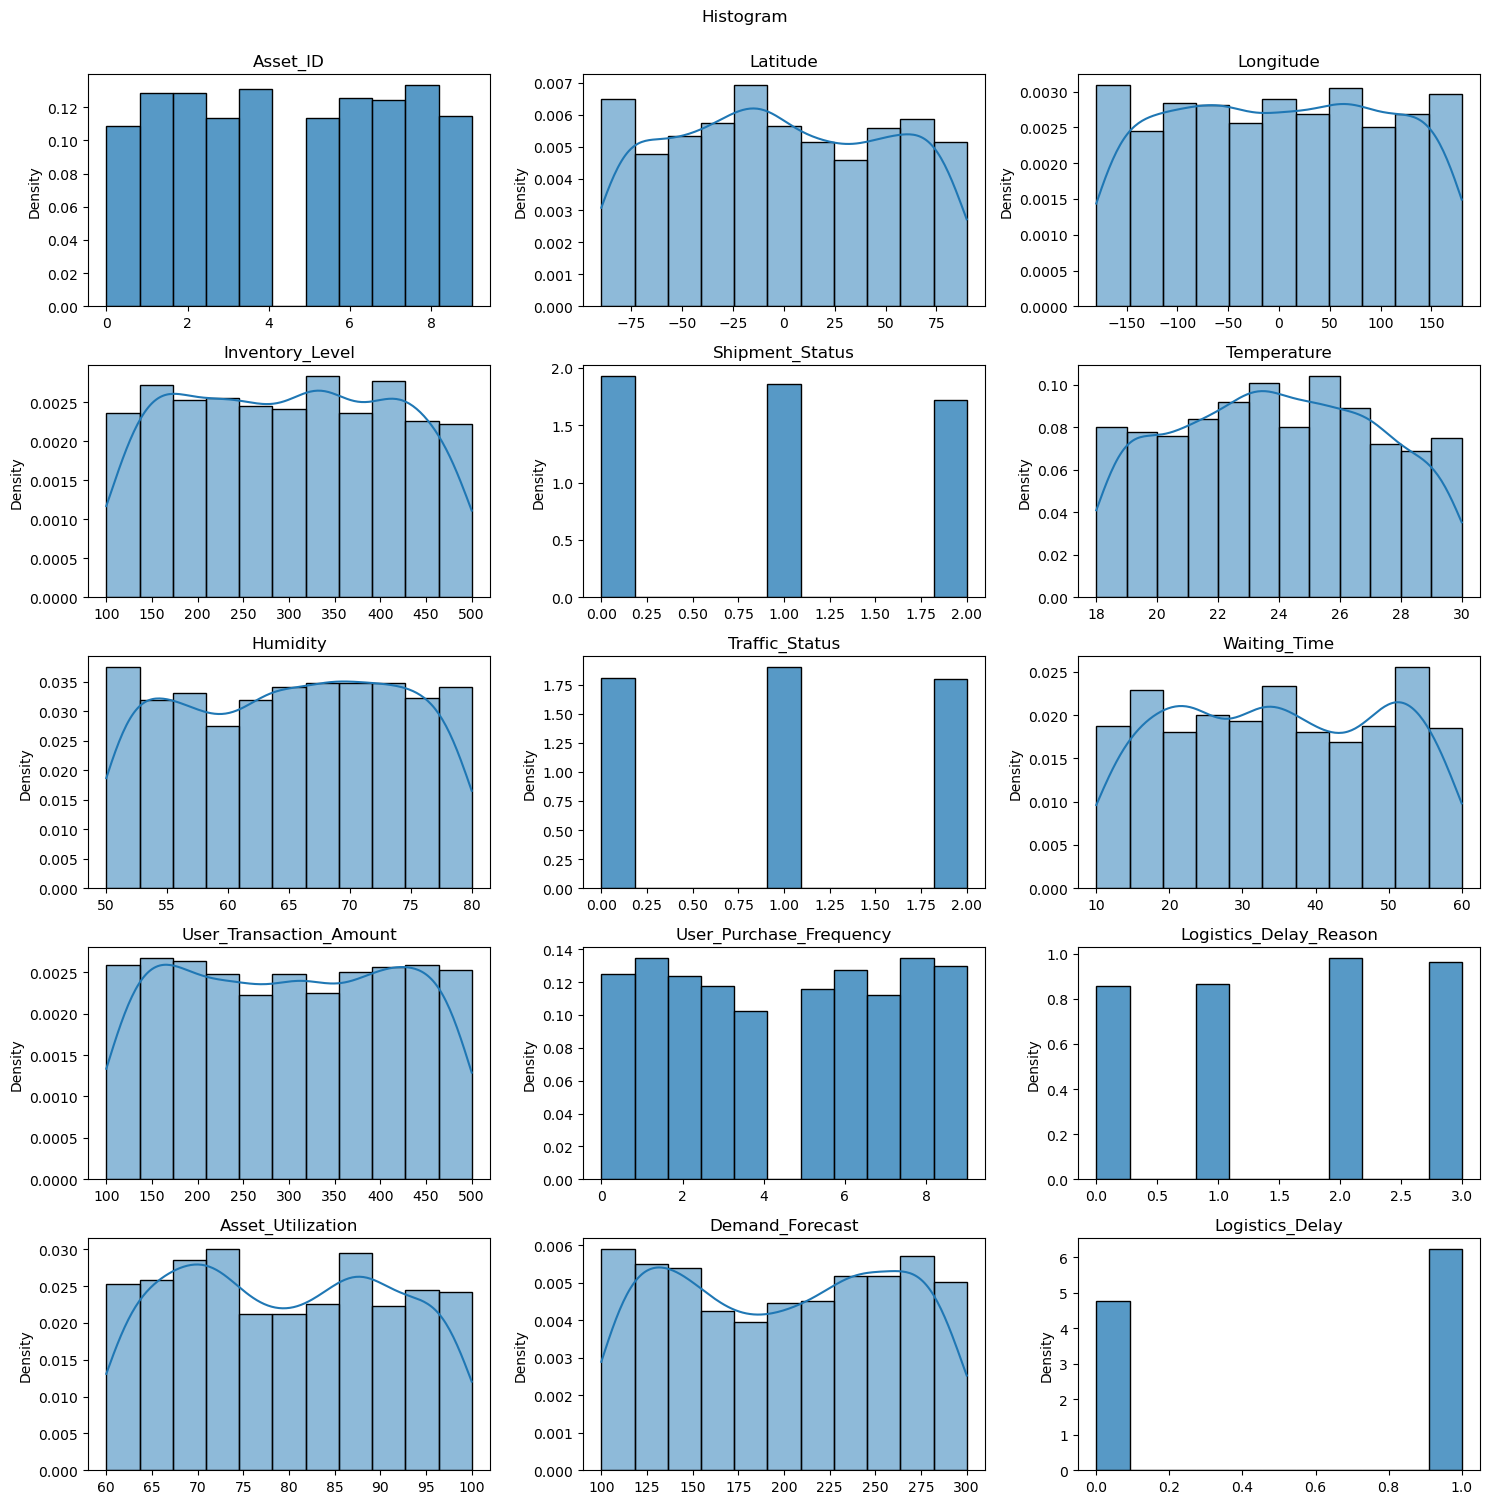

In [6]:
dta.dist_plot()

100%|█████████████████████████████████████████| 120/120 [00:03<00:00, 31.92it/s]


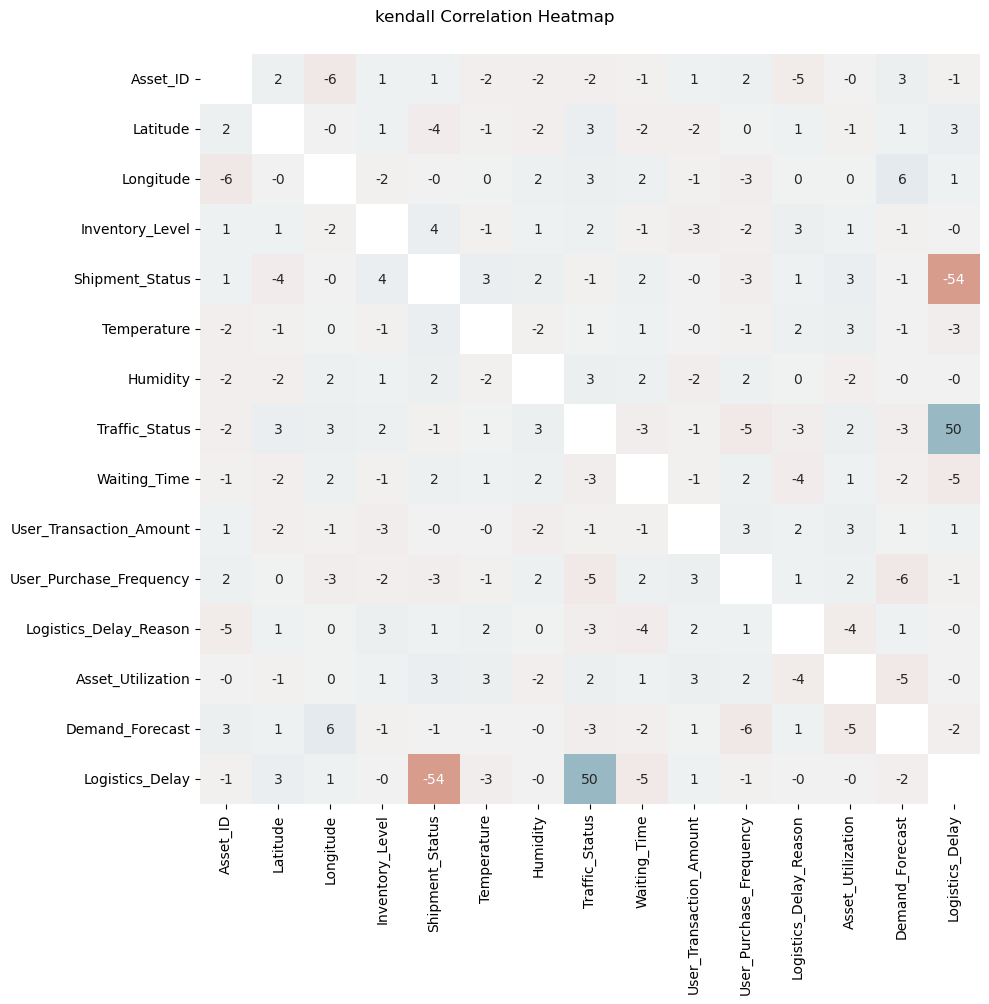

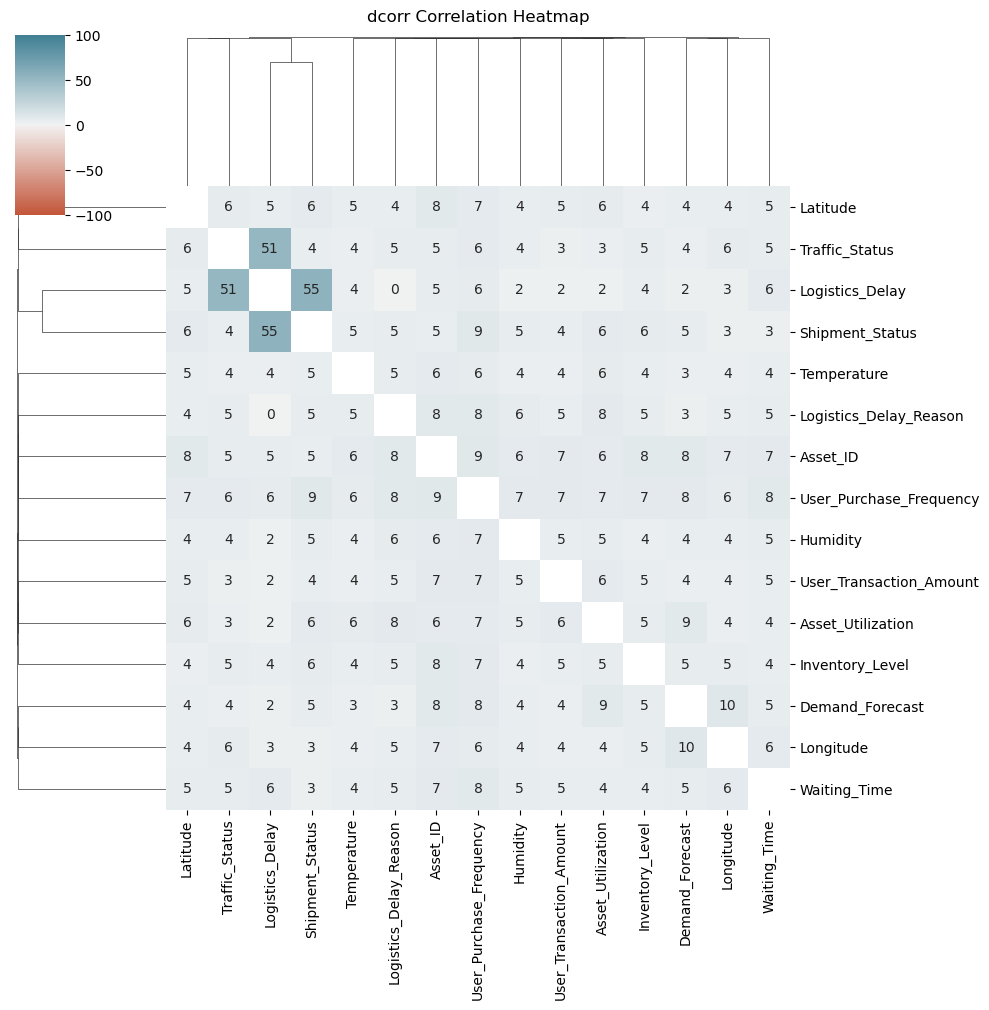

In [7]:
dta.corr_heatmap(corr_method='kendall', cluster=False);
dta.corr_heatmap(corr_method='dcorr', cluster=True);

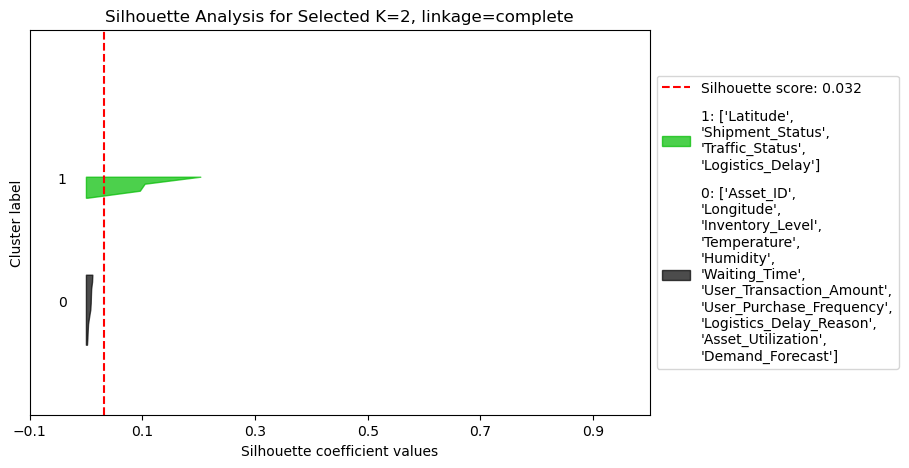

In [8]:
dta.cluster_features(figsize=(8, 5));

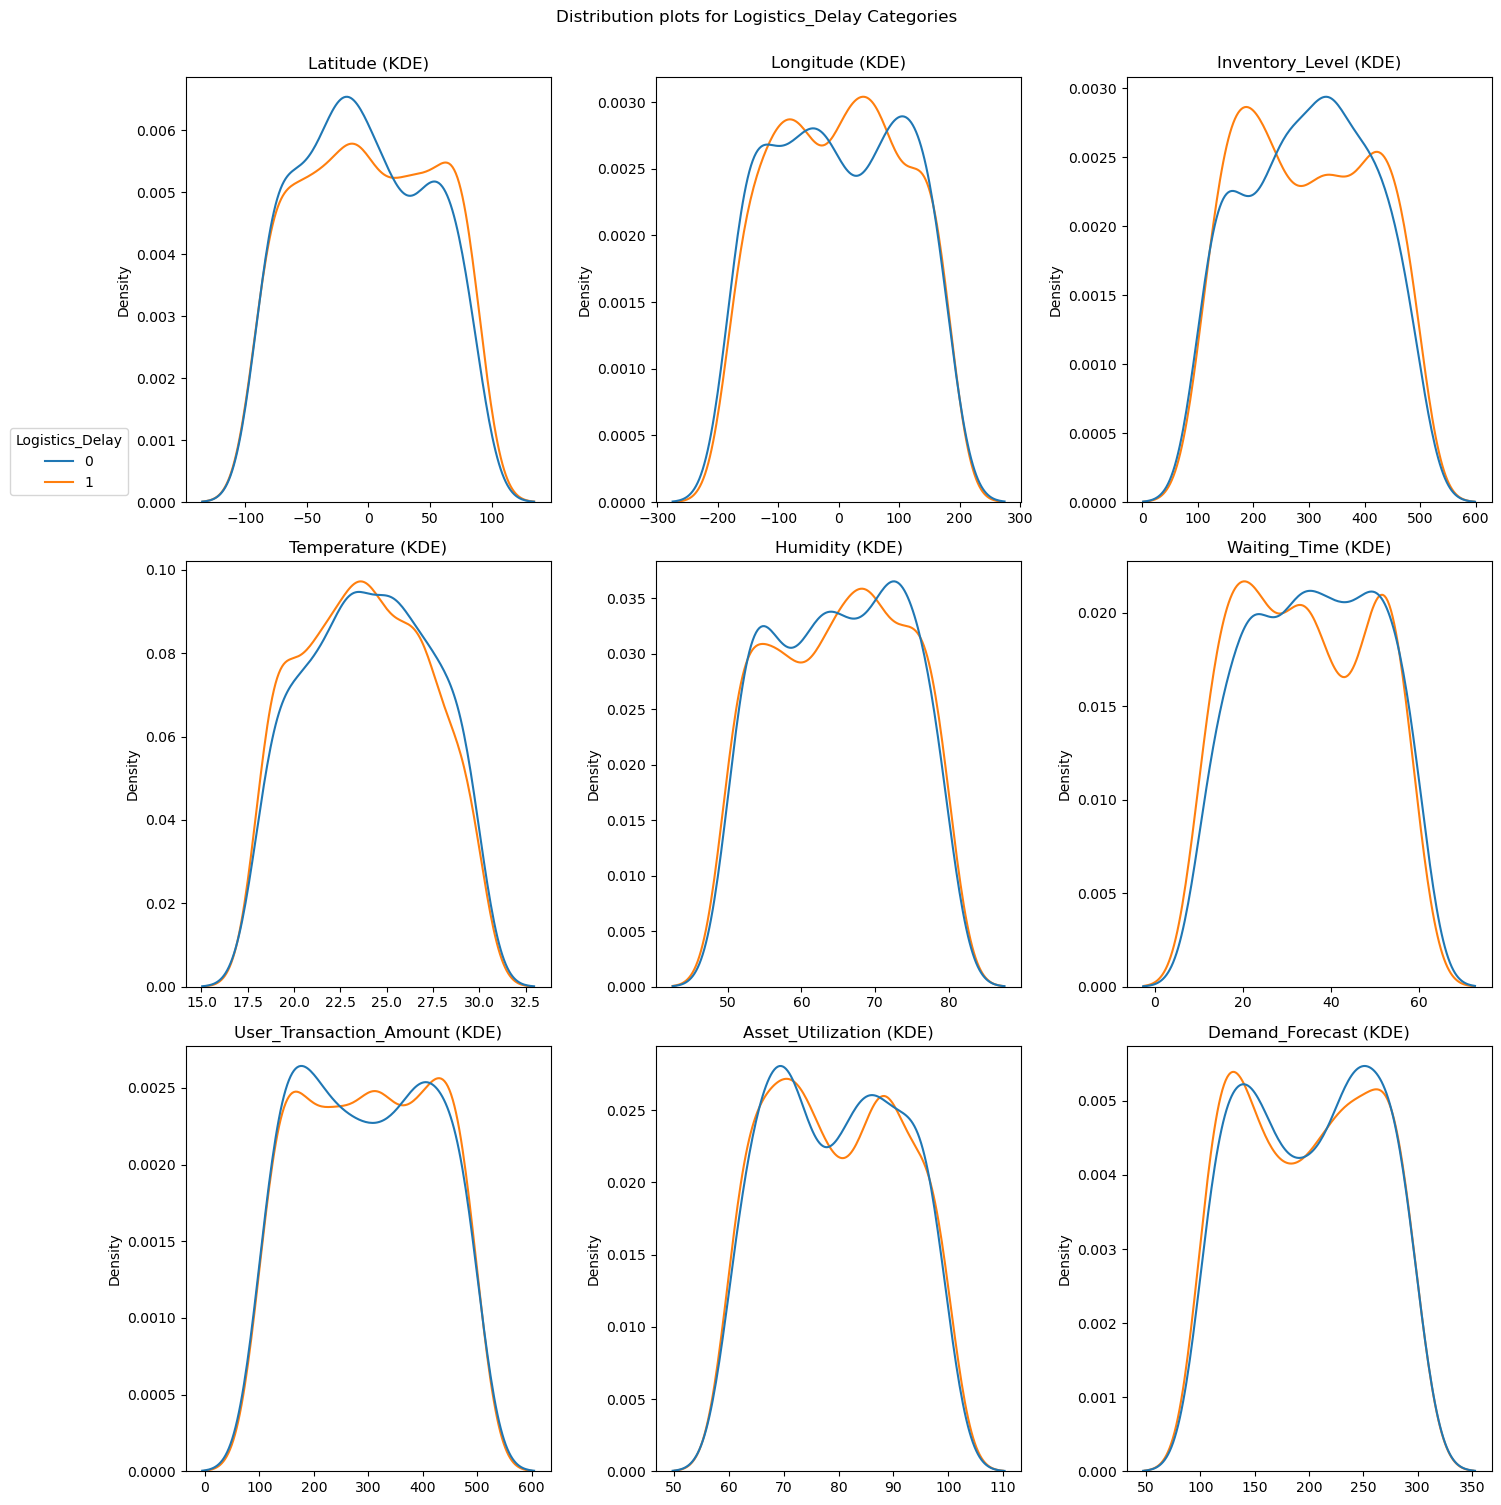

In [9]:
dta.dist_plot_by_categ('Logistics_Delay')

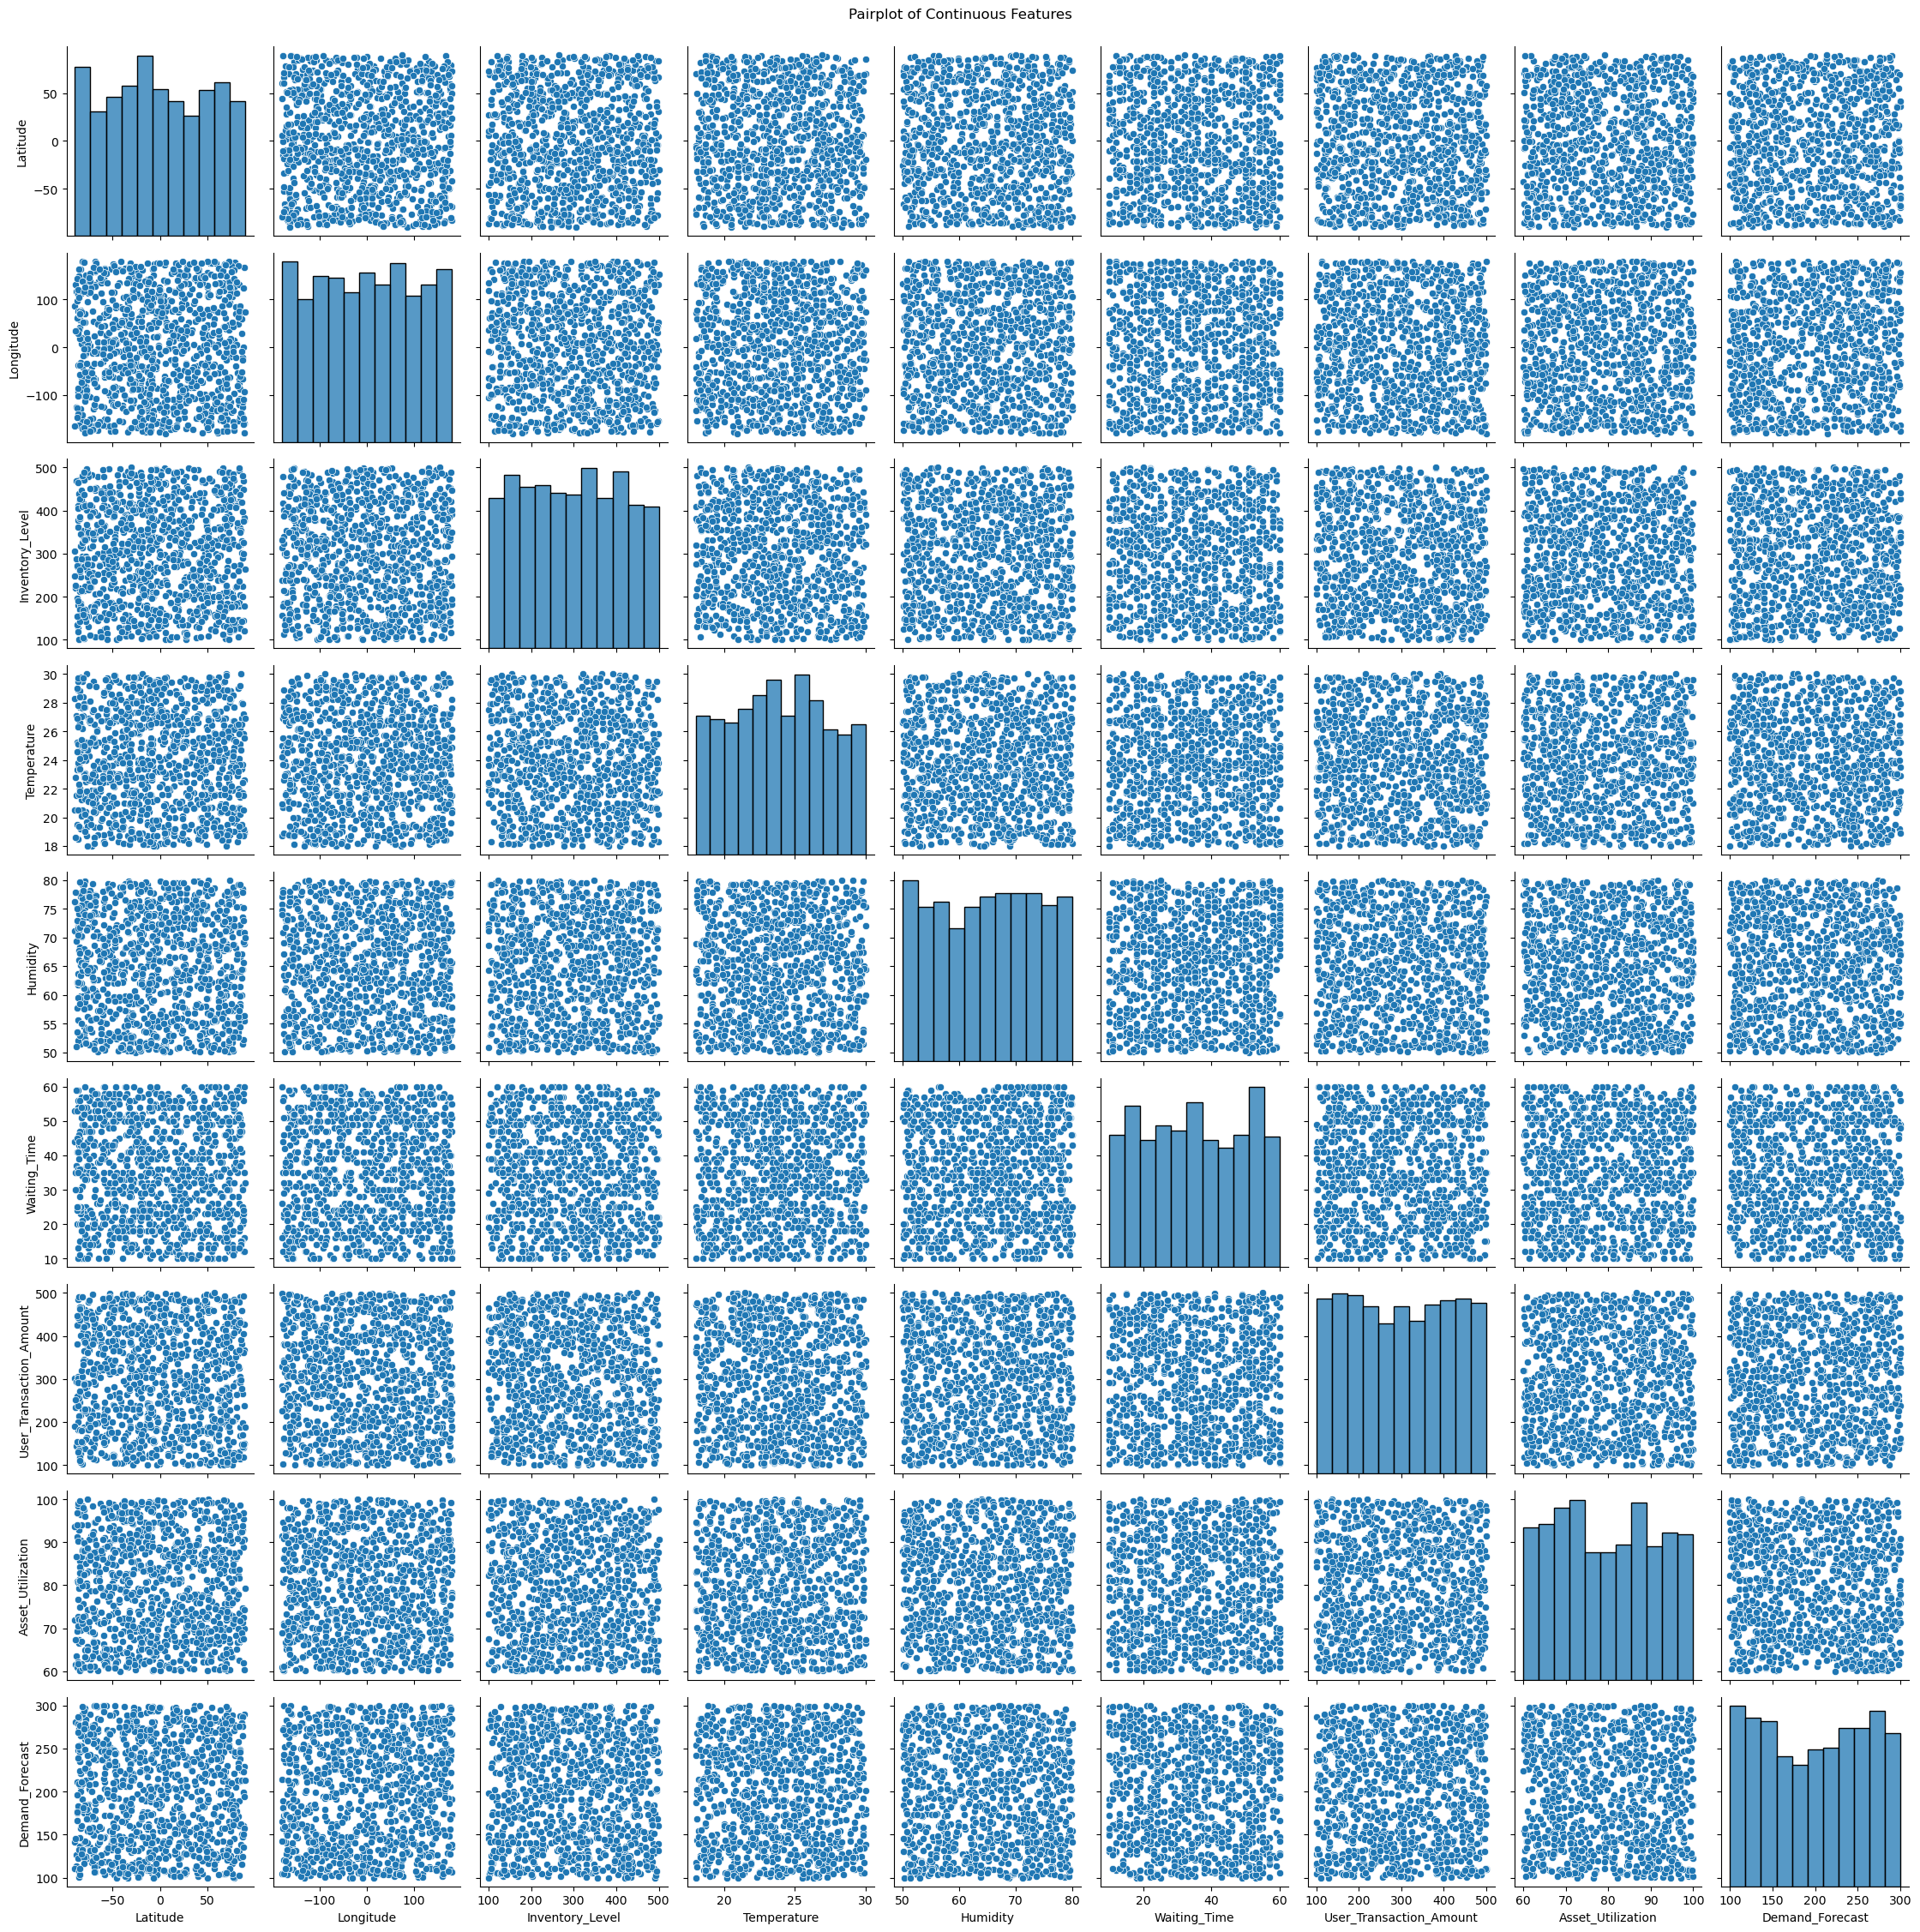

In [10]:
dta.pairplot();

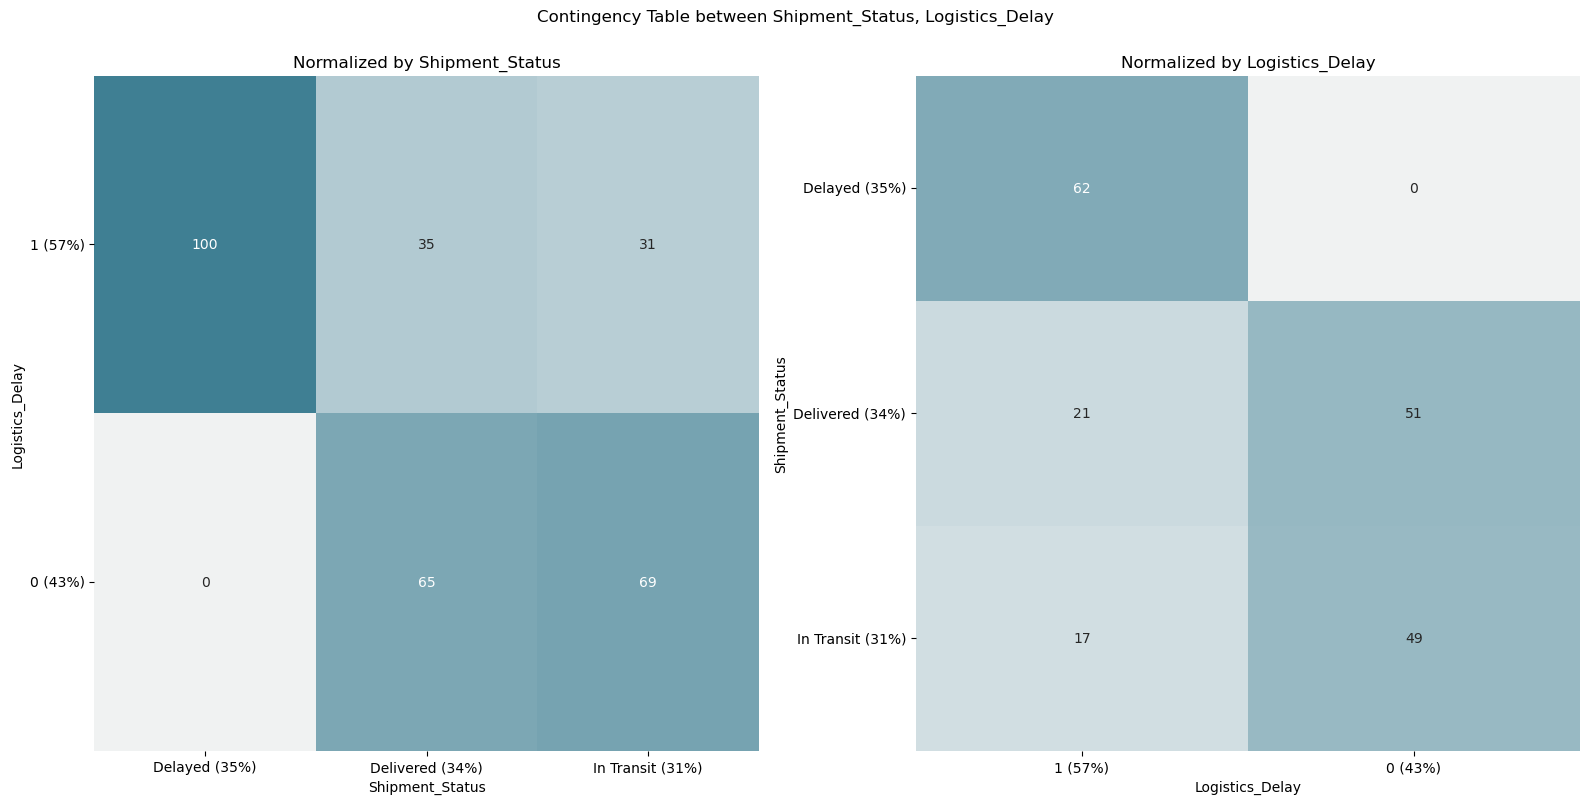

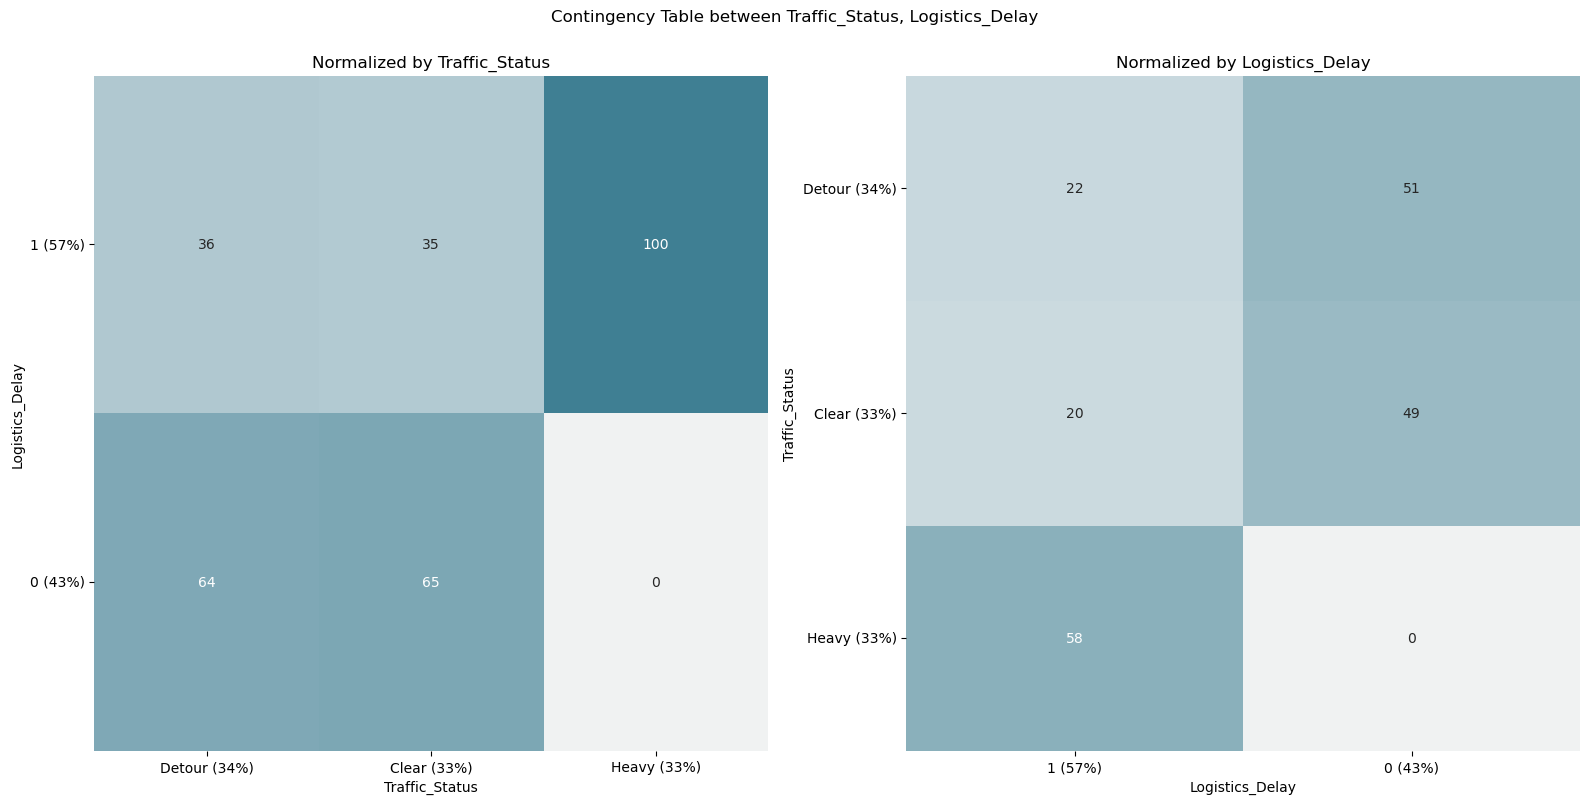

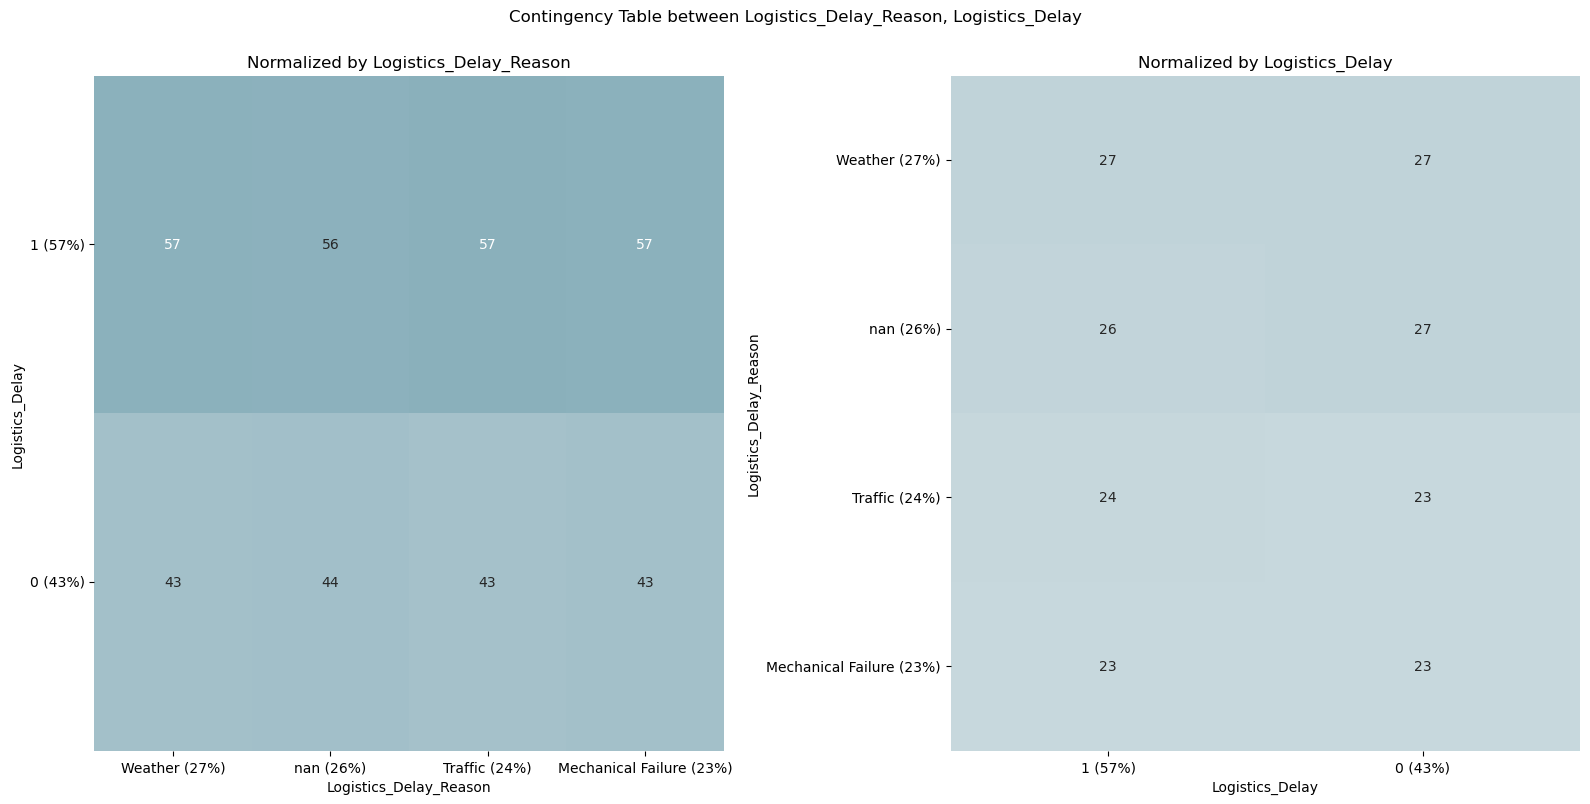

In [11]:
dta.plot_contingency('Shipment_Status', 'Logistics_Delay');
dta.plot_contingency('Traffic_Status', 'Logistics_Delay');
#dta.plot_contingency('Traffic_Status', 'Shipment_Status');

dta.plot_contingency('Logistics_Delay_Reason', 'Logistics_Delay');

In [12]:
# dta.df.to_csv('../Processed/SmartLog.csv')
# print(dta.cont_cols)